https://habr.com/ru/companies/skillfactory/articles/721838/

In [1]:
import networkx as nx

from graph_storage import GraphStorage

In [2]:
gs = GraphStorage(path_to_storage_file='db.json')

In [3]:
# db = {
#     "img1.jpg": ("кот", "рама", "мыть"),
#     "img2.jpg": ("мама", "кот", "гладить"),
# }

In [4]:
db = gs.data
db

{'Снимок экрана от 2026-03-15 11-27-39.png': [['мальчик', 'шар', 'прыгать на'],
  ['мальчик', 'конус', 'перед'],
  ['мальчик', 'конус', 'за'],
  ['шар', 'пол', 'над'],
  ['конус', 'пол', 'на'],
  ['мальчик', 'сетка', 'под'],
  ['ребёнок', 'сетка', 'под'],
  ['ребёнок', 'стена', 'у'],
  ['стена', 'пол', 'над'],
  ['шар', 'рука', 'в'],
  ['мальчик', 'гимнастический зал', 'в'],
  ['ребёнок', 'гимнастический зал', 'в'],
  ['конус', 'гимнастический зал', 'в'],
  ['шар', 'гимнастический зал', 'в']],
 'Снимок экрана от 2026-03-15 11-25-14.png': [['мальчик в белый форма',
   'мяч',
   'направляться к'],
  ['мальчик в красный форма', 'мяч', 'направляться к'],
  ['мальчик в белый форма #7', 'поле', 'находиться на'],
  ['мальчик в белый форма', 'поле', 'находиться на'],
  ['мальчик в красный форма', 'поле', 'находиться на'],
  ['мяч', 'поле', 'находиться на'],
  ['мальчик в белый форма', 'мальчик в красный форма', 'взаимодействовать'],
  ['мальчик в белый форма #7', 'мальчик в белый форма', 'взаи

In [5]:
# def draw_graph(db, G = nx.DiGraph(directed=True)):
#     # G = nx.DiGraph(directed=True)

#     draw_dict = {}
#     for img_name, db_item in db.items():
#         print(img_name, db_item)

#         G.add_nodes_from([db_item[0], db_item[1]])

#         G.add_edge(db_item[0], db_item[1])



#         draw_dict[(db_item[0], db_item[1])] = db_item[2]


#     # set layout
#     pos = nx.circular_layout(G)

#     # draw graph
#     nx.draw(G, pos, with_labels = True)

#     # draw edge labels
#     nx.draw_networkx_edge_labels(
#         G, pos,
#         edge_labels=draw_dict,
#         font_color='red'
#     )
    



In [6]:
def draw_graph(img_name, img_data, G = nx.DiGraph(directed=True)):
    # G = nx.DiGraph(directed=True)

    draw_dict = {}
    for graphs in img_data:
        print(img_name, graphs)

        G.add_nodes_from([graphs[0], graphs[1]])

        G.add_edge(graphs[0], graphs[1])

        draw_dict[(graphs[0], graphs[1])] = graphs[2]


    # set layout
    pos = nx.circular_layout(G)

    # draw graph
    nx.draw(G, pos, with_labels = True)

    # draw edge labels
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=draw_dict,
        font_color='red'
    )
    



Снимок экрана от 2026-03-15 11-27-39.png ['мальчик', 'шар', 'прыгать на']
Снимок экрана от 2026-03-15 11-27-39.png ['мальчик', 'конус', 'перед']
Снимок экрана от 2026-03-15 11-27-39.png ['мальчик', 'конус', 'за']
Снимок экрана от 2026-03-15 11-27-39.png ['шар', 'пол', 'над']
Снимок экрана от 2026-03-15 11-27-39.png ['конус', 'пол', 'на']
Снимок экрана от 2026-03-15 11-27-39.png ['мальчик', 'сетка', 'под']
Снимок экрана от 2026-03-15 11-27-39.png ['ребёнок', 'сетка', 'под']
Снимок экрана от 2026-03-15 11-27-39.png ['ребёнок', 'стена', 'у']
Снимок экрана от 2026-03-15 11-27-39.png ['стена', 'пол', 'над']
Снимок экрана от 2026-03-15 11-27-39.png ['шар', 'рука', 'в']
Снимок экрана от 2026-03-15 11-27-39.png ['мальчик', 'гимнастический зал', 'в']
Снимок экрана от 2026-03-15 11-27-39.png ['ребёнок', 'гимнастический зал', 'в']
Снимок экрана от 2026-03-15 11-27-39.png ['конус', 'гимнастический зал', 'в']
Снимок экрана от 2026-03-15 11-27-39.png ['шар', 'гимнастический зал', 'в']


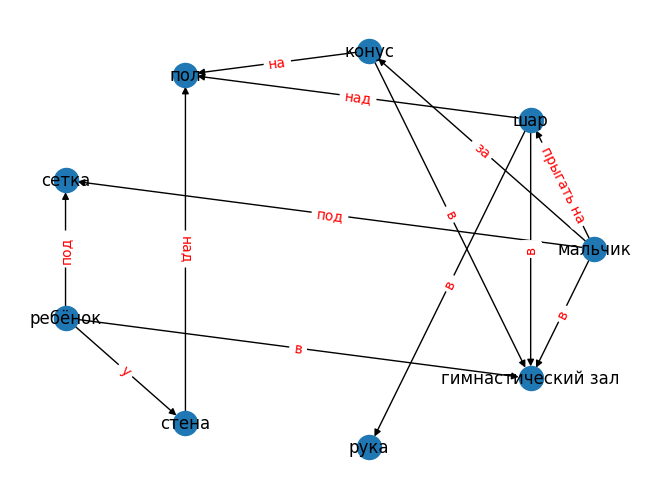

In [7]:
for img_name, img_data in db.items():
    draw_graph(img_name, img_data)
    break

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Исходные данные
# data = {
#     'img1': [['кот', 'рама', 'мыть'], ['мама', 'кот', 'гладить']],
#     'img2': [['мальчик1', 'мяч', 'бьет'], ['мяч', 'ворота', 'летит']],
#     'img3': [['мальчик2', 'мальчик1', 'бьет']],
#     'img3 ааа.jpg': [['мальчик2', 'мальчик1', 'бьет']]
# }

# Функция для построения и отображения графа
def build_and_show_graph(image_name, triples):
    # Создаем направленный граф
    G = nx.DiGraph()
    
    # Добавляем ребра: (субъект, объект, действие)
    for subj, obj, action in triples:
        G.add_edge(subj, obj, label=action)
    
    # Проверка на пустой граф
    if len(G.nodes()) == 0:
        print(f"Для {image_name} нет данных для построения графа.")
        return
    
    # Создаем рисунок
    plt.figure(figsize=(6, 4))
    
    # Определяем расположение узлов (для красоты)
    pos = nx.spring_layout(G, seed=42, k=1.5)  # k регулирует расстояние между узлами
    
    # Рисуем узлы и ребра
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    # Рисуем стрелки (ребра)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, 
                           connectionstyle='arc3,rad=0.1')  # rad для изогнутых линий
    
    # Добавляем подписи к ребрам (действия)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    
    # Настраиваем отображение
    plt.title(f"Граф для {image_name}")
    plt.axis('off')  # Убираем оси координат
    plt.tight_layout()
    plt.show()



In [9]:
data = db

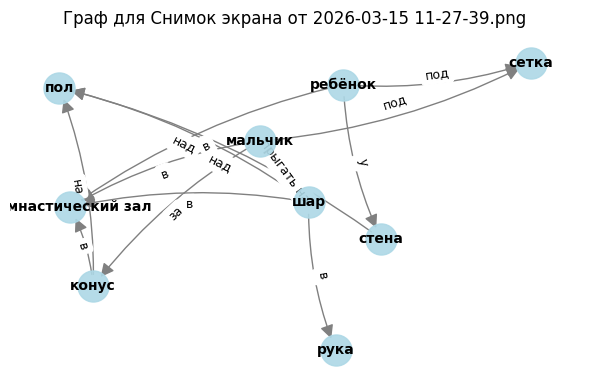

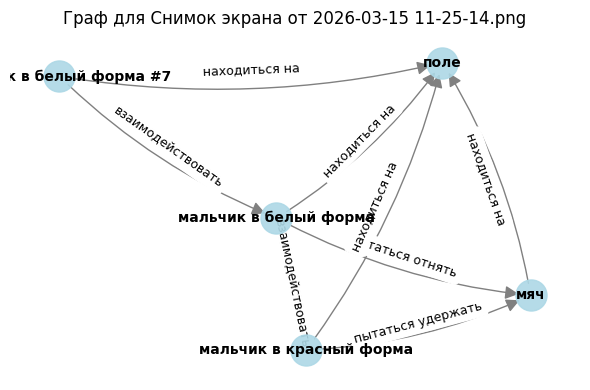

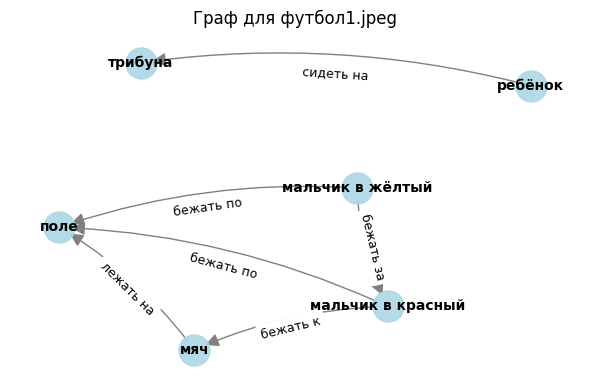

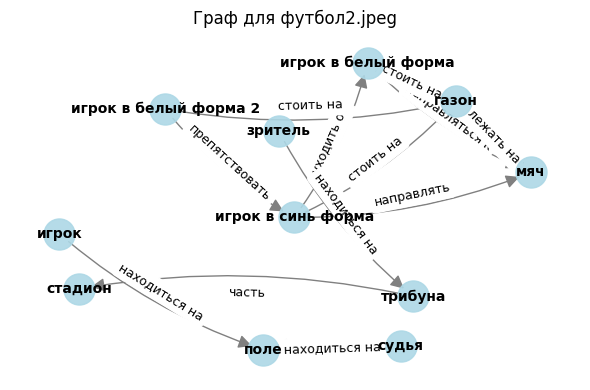

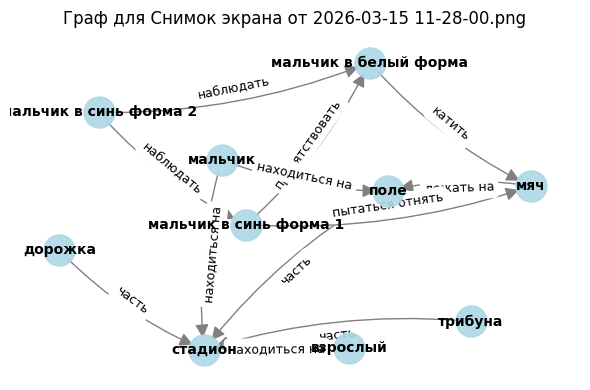

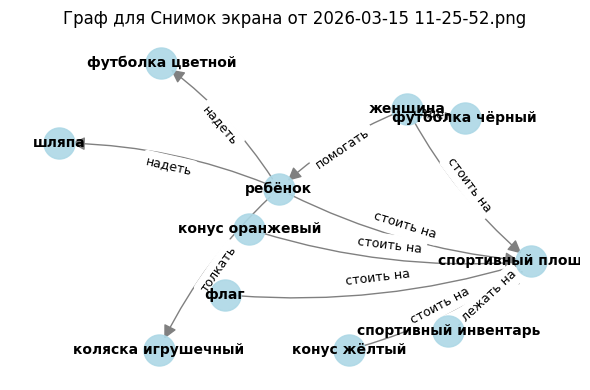

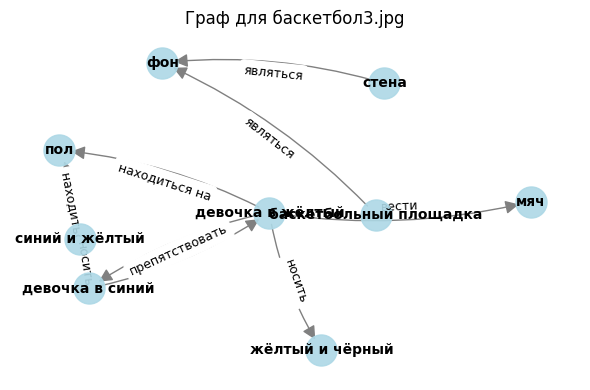

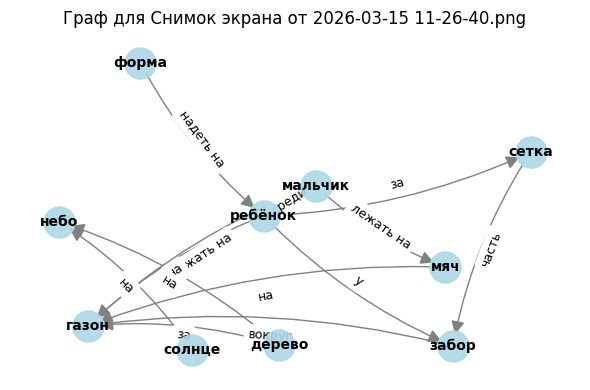

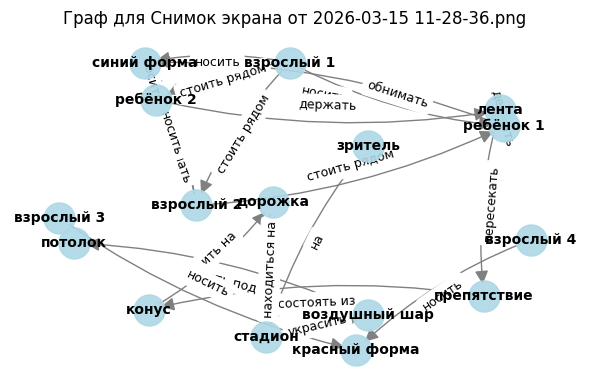

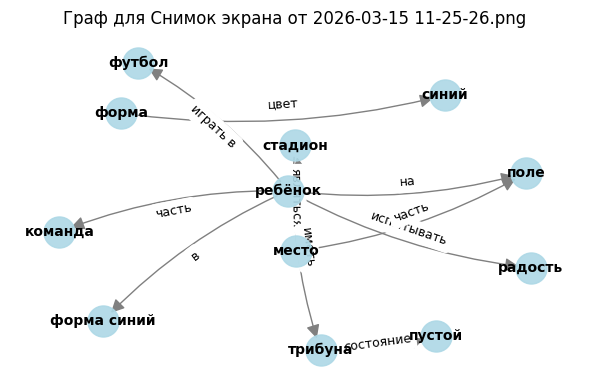

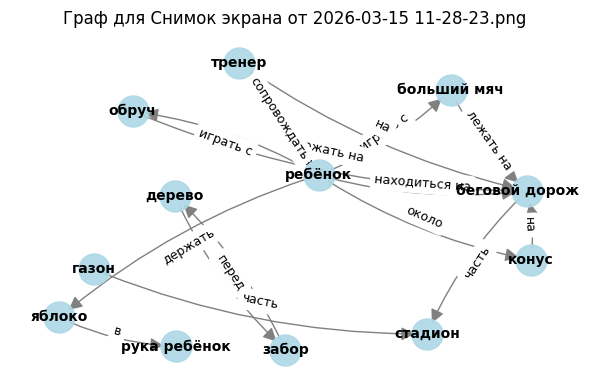

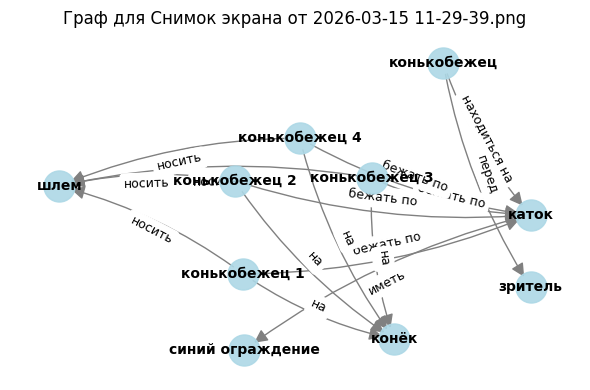

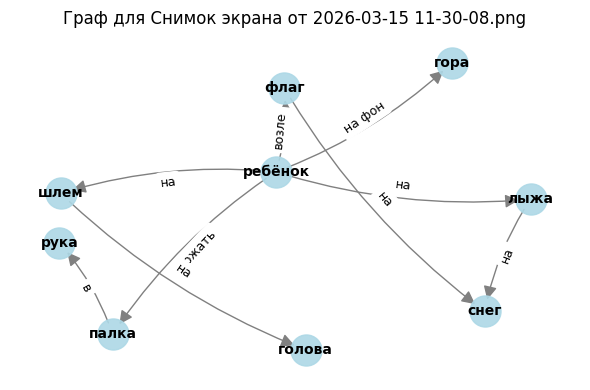

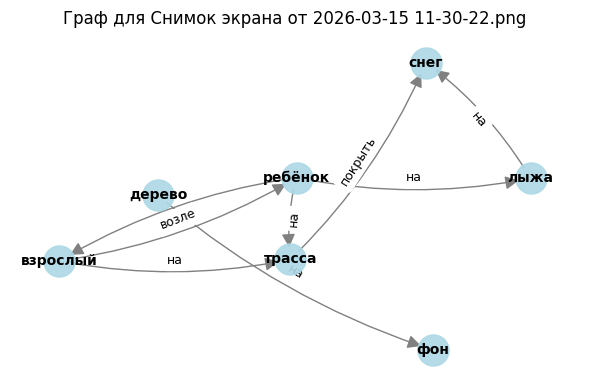

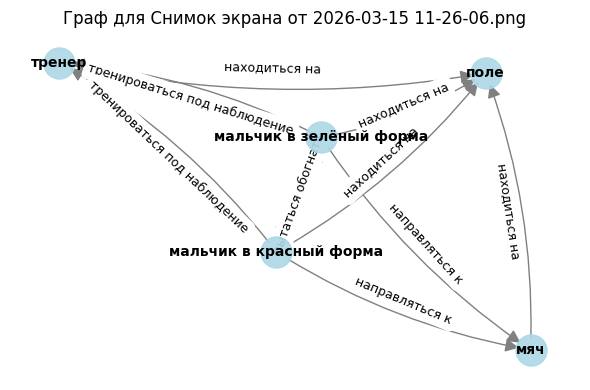

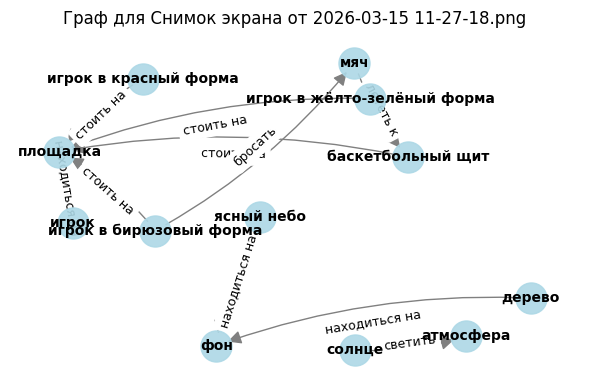

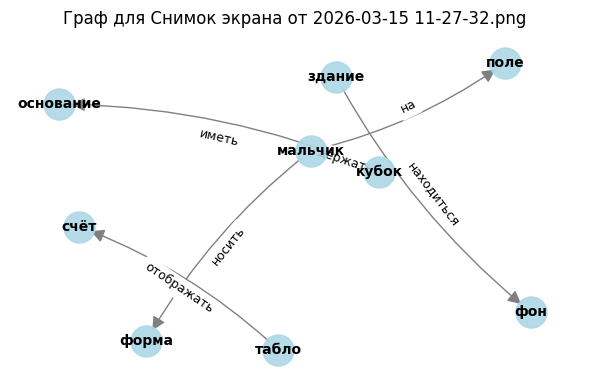

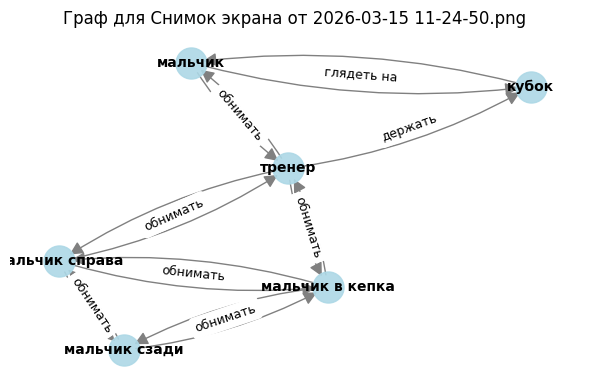

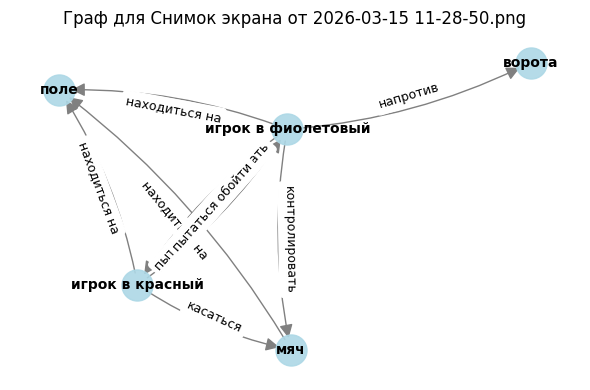

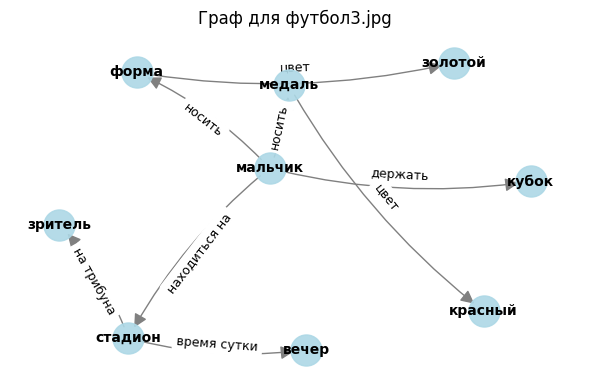

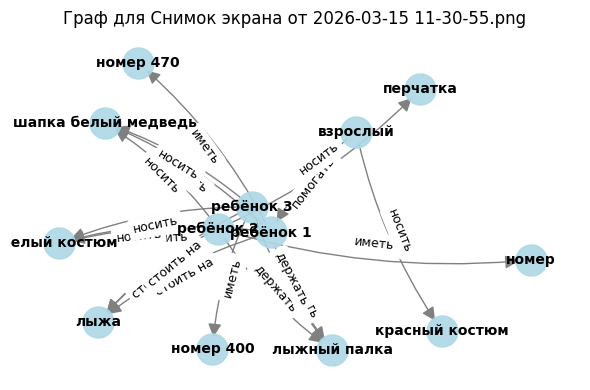

/Users/admin/deaplearning/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/deaplearning/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


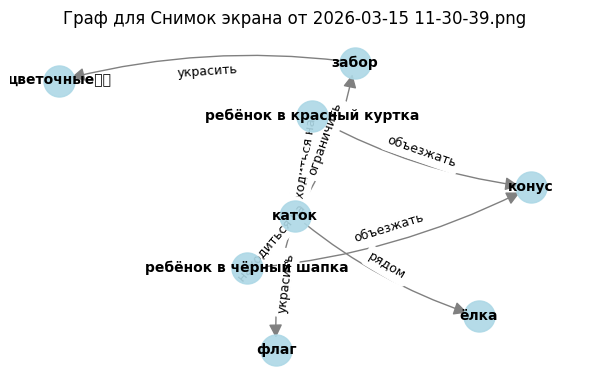

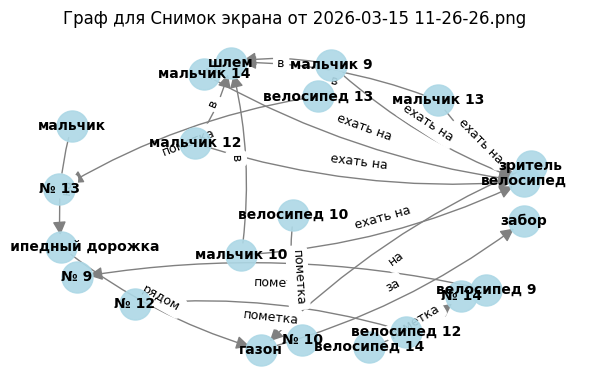

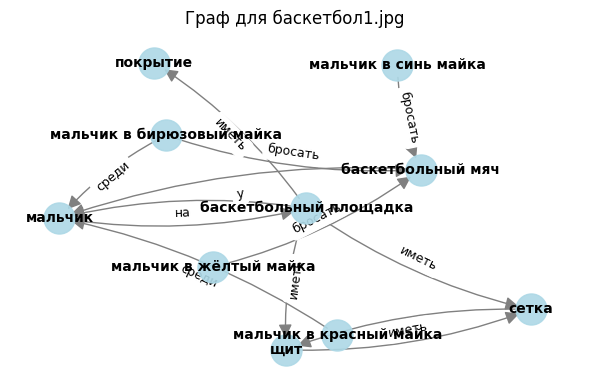

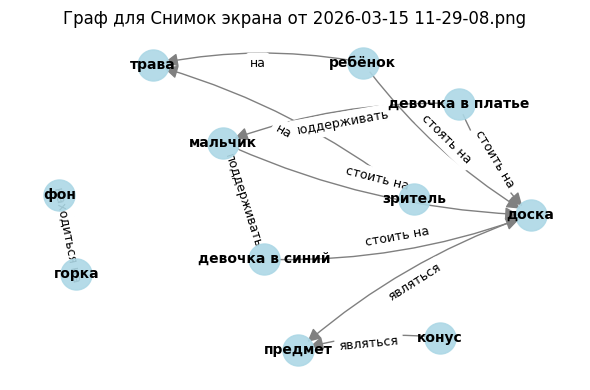

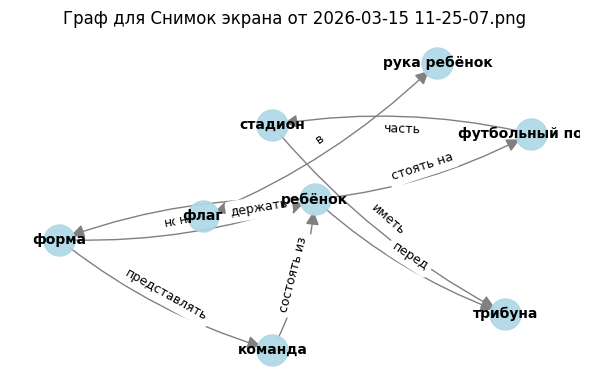

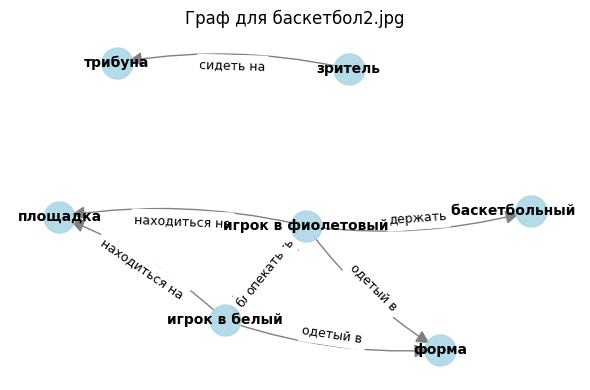

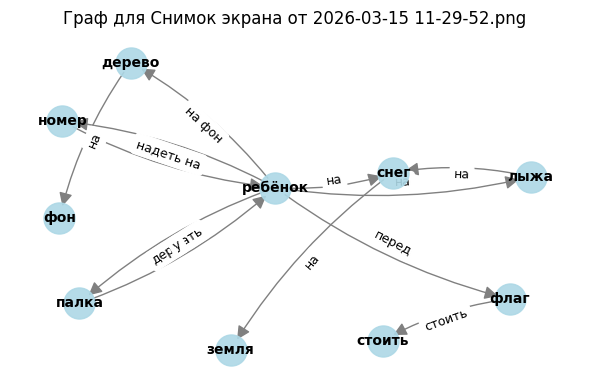


--- Структура графов (Adjacency List) ---

Снимок экрана от 2026-03-15 11-27-39.png:
  мальчик --(прыгать на)--> шар
  мальчик --(за)--> конус
  мальчик --(под)--> сетка
  мальчик --(в)--> гимнастический зал
  шар --(над)--> пол
  шар --(в)--> рука
  шар --(в)--> гимнастический зал
  конус --(на)--> пол
  конус --(в)--> гимнастический зал
  ребёнок --(под)--> сетка
  ребёнок --(у)--> стена
  ребёнок --(в)--> гимнастический зал
  стена --(над)--> пол

Снимок экрана от 2026-03-15 11-25-14.png:
  мальчик в белый форма --(пытаться отнять)--> мяч
  мальчик в белый форма --(находиться на)--> поле
  мальчик в белый форма --(взаимодействовать)--> мальчик в красный форма
  мяч --(находиться на)--> поле
  мальчик в красный форма --(пытаться удержать)--> мяч
  мальчик в красный форма --(находиться на)--> поле
  мальчик в белый форма #7 --(находиться на)--> поле
  мальчик в белый форма #7 --(взаимодействовать)--> мальчик в белый форма

футбол1.jpeg:
  мальчик в жёлтый --(бежать за)--> мальчик в к

In [10]:
# Строим граф для каждого изображения
for img, triples in data.items():
    build_and_show_graph(img, triples)

# --- Дополнительно: Вывод данных в виде структуры (если картинка не нужна) ---
print("\n--- Структура графов (Adjacency List) ---")
for img, triples in data.items():
    G = nx.DiGraph()
    for subj, obj, action in triples:
        G.add_edge(subj, obj, action=action)
    
    print(f"\n{img}:")
    for node in G.nodes():
        edges_from_node = G.edges(node, data=True)
        if edges_from_node:
            for _, target, data in edges_from_node:
                print(f"  {node} --({data['action']})--> {target}")